In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [11]:
ROOT = Path().resolve().parent  # sube un nivel desde notebooks/
DATA_RAW =  ROOT / 'data' / 'raw'

In [12]:
df = pd.read_csv(DATA_RAW/'heloc_dataset.csv')
df["target"] =  (df['RiskPerformance'] == 'Bad').astype(int)

print(df.shape)
df.head()

(10459, 25)


,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,target
0,Bad,55,144,4,84,20,3,0,83,2,...,0,0,0,33,-8,8,1,1,69,1
1,Bad,61,58,15,41,2,4,4,100,-7,...,0,0,0,0,-8,0,-8,-8,0,1
2,Bad,67,66,5,24,9,0,0,100,-7,...,0,4,4,53,66,4,2,1,86,1
3,Bad,66,169,1,73,28,1,1,93,76,...,0,5,4,72,83,6,4,3,91,1
4,Bad,81,333,27,132,12,0,0,100,-7,...,0,1,1,51,89,3,1,0,80,1


In [13]:
X = df.drop(columns=['RiskPerformance', 'target'])
y = df['target']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# eda sobre esto
df_eda = X_train.copy()
df_eda['target'] = y_train.values

In [15]:
df_eda

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,target
6682,80,136,15,63,11,0,0,91,21,6,...,-7,1,1,19,54,2,3,0,71,0
4977,91,342,42,130,14,0,0,100,-7,7,...,-8,0,0,3,-8,2,2,0,50,0
9991,56,193,46,88,22,0,0,78,3,4,...,0,1,1,64,37,8,2,4,83,1
984,63,250,27,76,12,0,0,75,1,4,...,0,2,2,36,11,5,1,0,75,1
797,72,255,13,60,31,0,0,100,-7,7,...,13,0,0,85,14,9,2,9,79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8991,79,135,3,59,29,0,0,100,-7,7,...,0,1,1,2,51,2,4,1,60,0
75,78,134,2,63,35,0,0,93,32,6,...,0,0,0,22,55,5,4,0,60,0
7239,84,160,4,70,18,0,0,100,-7,7,...,0,0,0,26,97,2,2,0,40,0
6531,61,137,2,52,12,1,1,93,6,2,...,0,2,2,22,-8,2,1,0,67,1


In [16]:
df_eda.isnull().sum()

ExternalRiskEstimate                  0
MSinceOldestTradeOpen                 0
MSinceMostRecentTradeOpen             0
AverageMInFile                        0
NumSatisfactoryTrades                 0
NumTrades60Ever2DerogPubRec           0
NumTrades90Ever2DerogPubRec           0
PercentTradesNeverDelq                0
MSinceMostRecentDelq                  0
MaxDelq2PublicRecLast12M              0
MaxDelqEver                           0
NumTotalTrades                        0
NumTradesOpeninLast12M                0
PercentInstallTrades                  0
MSinceMostRecentInqexcl7days          0
NumInqLast6M                          0
NumInqLast6Mexcl7days                 0
NetFractionRevolvingBurden            0
NetFractionInstallBurden              0
NumRevolvingTradesWBalance            0
NumInstallTradesWBalance              0
NumBank2NatlTradesWHighUtilization    0
PercentTradesWBalance                 0
target                                0
dtype: int64

In [17]:
df_eda.describe().round(2)

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,target
count,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,...,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00,8367.00
mean,67.31,184.18,8.51,73.84,19.40,0.05,-0.14,86.51,6.76,4.91,...,-0.32,0.85,0.80,31.63,39.06,3.19,0.96,0.01,62.12,0.52
std,21.24,109.52,13.33,38.87,12.99,2.55,2.40,26.20,20.47,3.78,...,6.09,3.21,3.18,30.00,41.87,4.42,4.06,3.34,27.72,0.50
min,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,...,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,0.00
25%,63.00,118.00,3.00,53.00,12.00,0.00,0.00,87.00,-7.00,4.00,...,-7.00,0.00,0.00,5.00,-8.00,2.00,1.00,0.00,48.00,0.00
50%,71.00,177.00,5.00,74.00,19.00,0.00,0.00,96.00,-7.00,6.00,...,0.00,1.00,1.00,25.00,47.00,3.00,2.00,0.00,67.00,1.00
75%,79.00,250.00,11.00,95.00,27.00,1.00,0.00,100.00,14.00,7.00,...,1.00,2.00,2.00,54.00,79.00,5.00,3.00,1.00,82.00,1.00
max,94.00,603.00,383.00,383.00,79.00,19.00,19.00,100.00,83.00,9.00,...,24.00,66.00,66.00,232.00,196.00,32.00,19.00,18.00,100.00,1.00


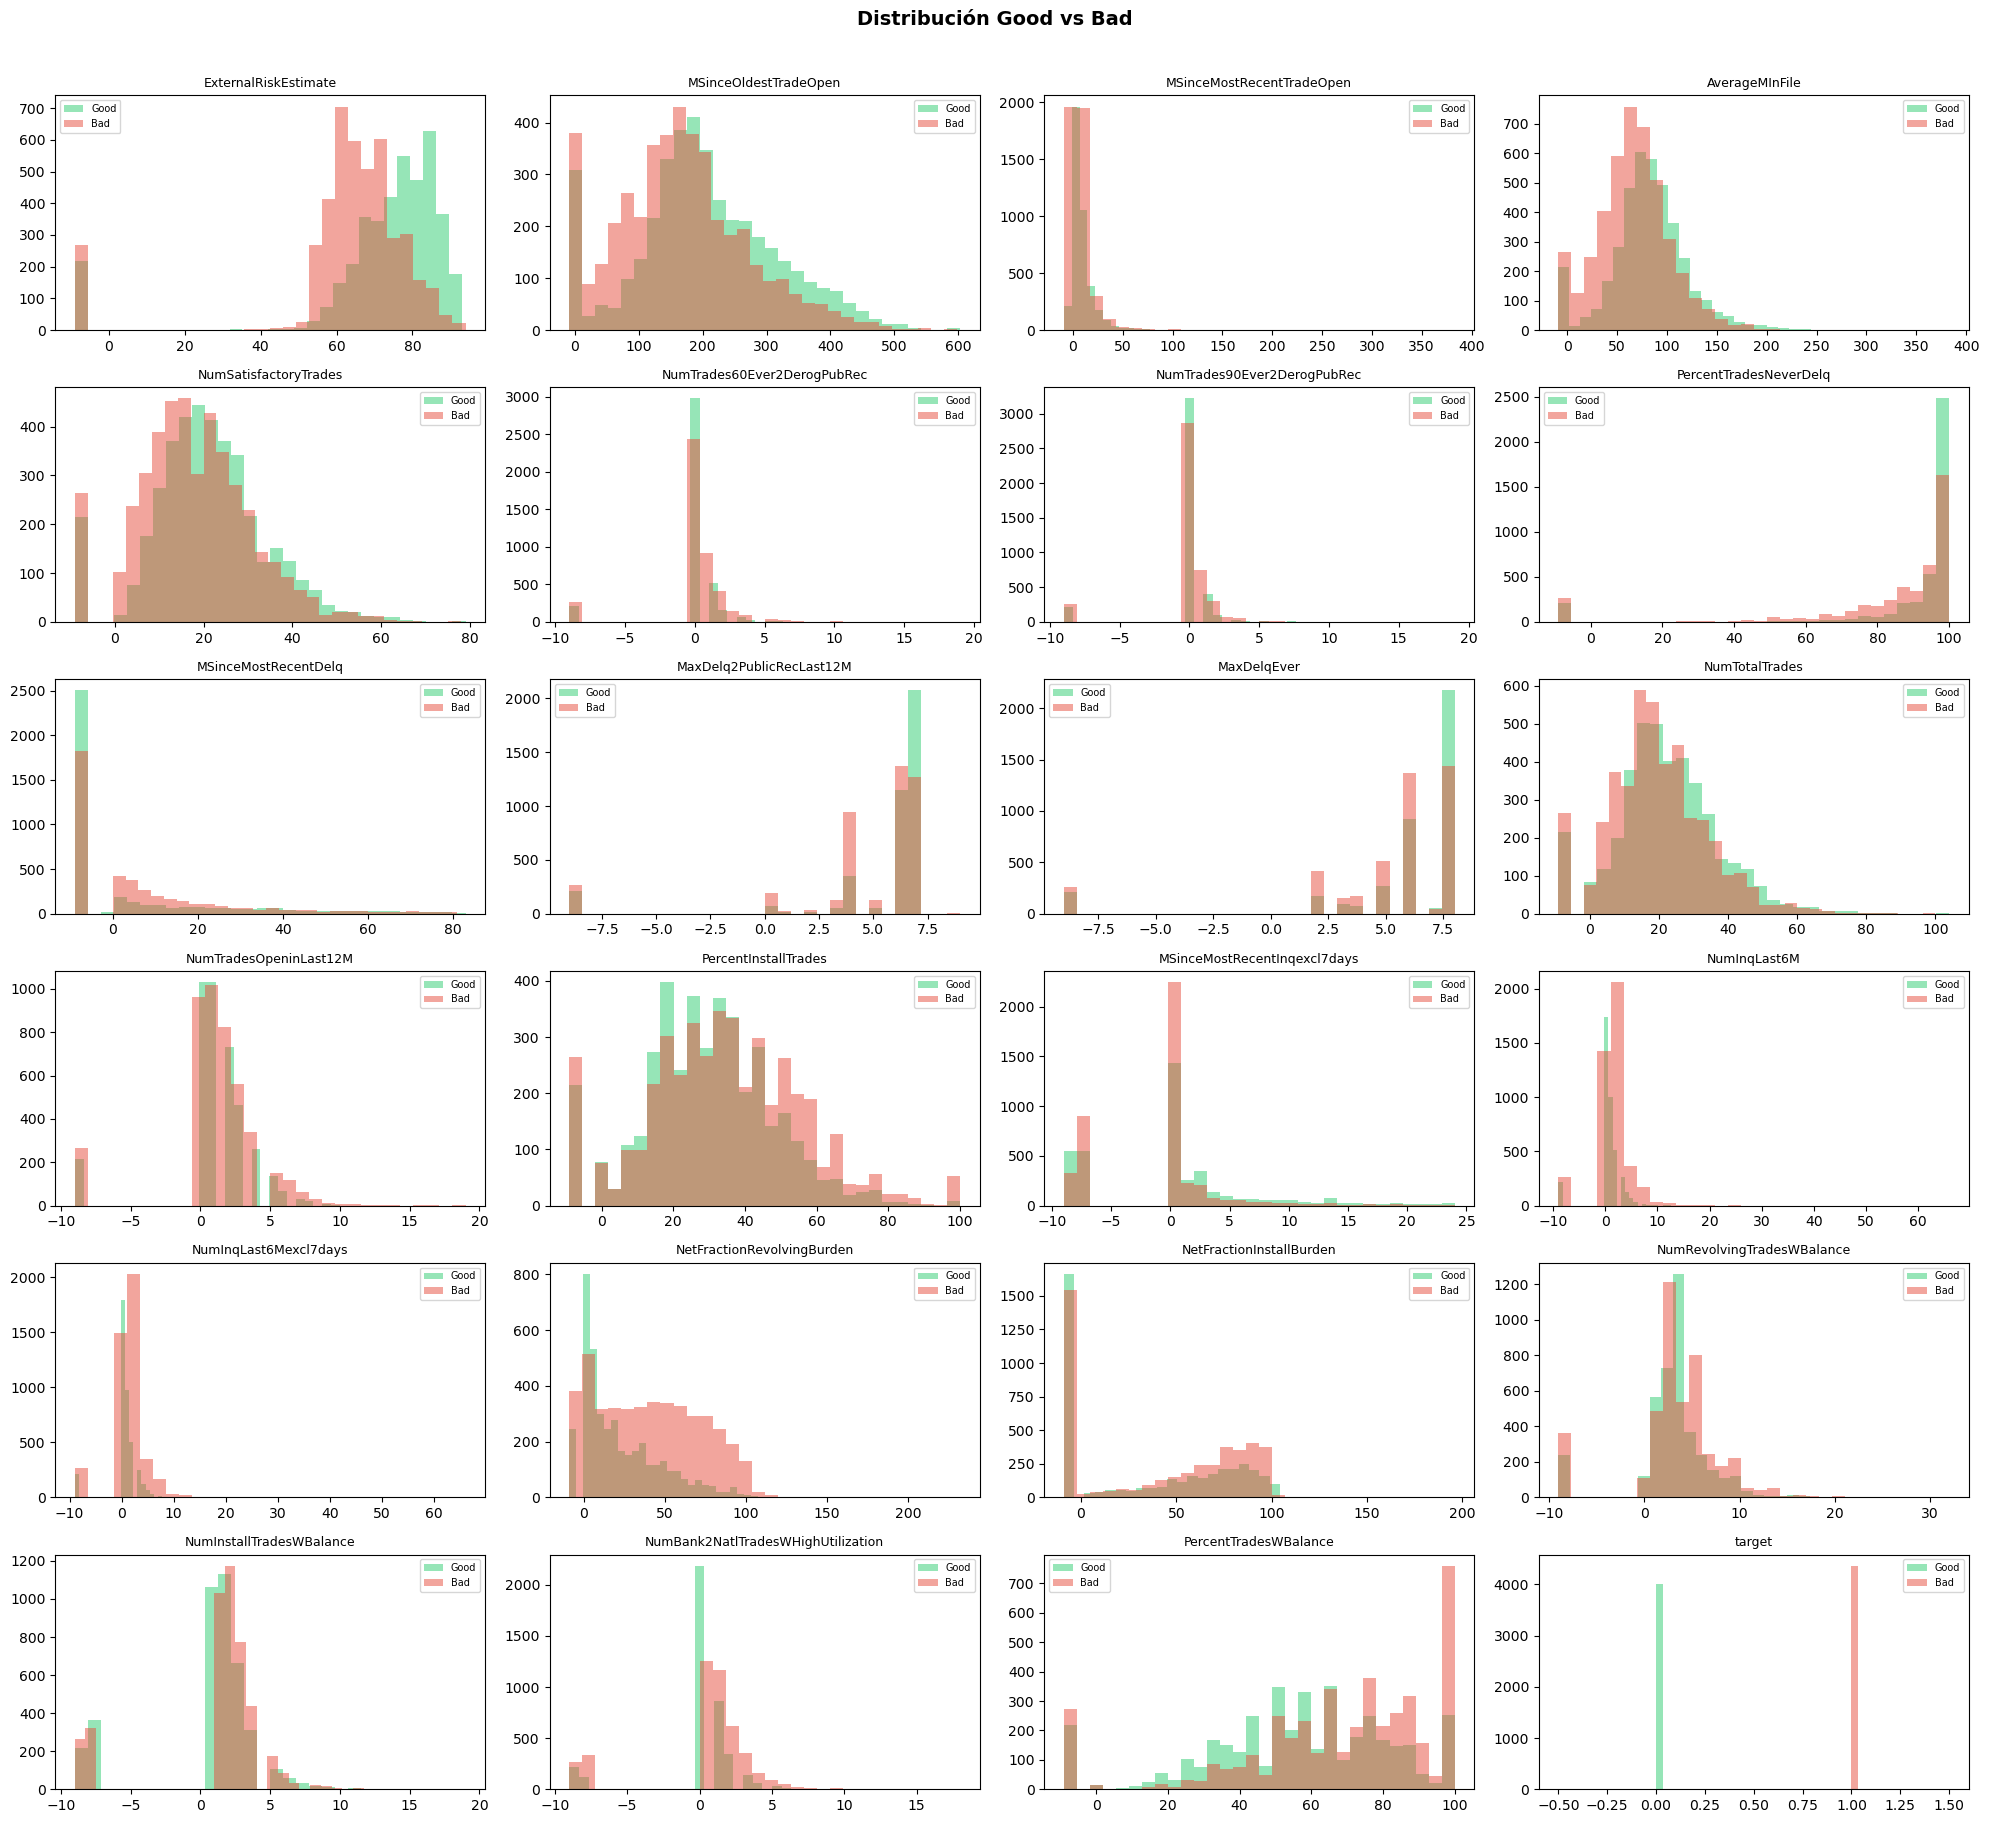

In [18]:
df_good = df_eda[df_eda['target'] == 0]
df_bad  = df_eda[df_eda['target'] == 1]

cols = df_eda.columns

fig, axes = plt.subplots(6, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df_good[col], bins=30, alpha=0.5, color='#2ecc71', label='Good')
    axes[i].hist(df_bad[col],  bins=30, alpha=0.5, color='#e74c3c', label='Bad')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

# Ocultar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución Good vs Bad', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

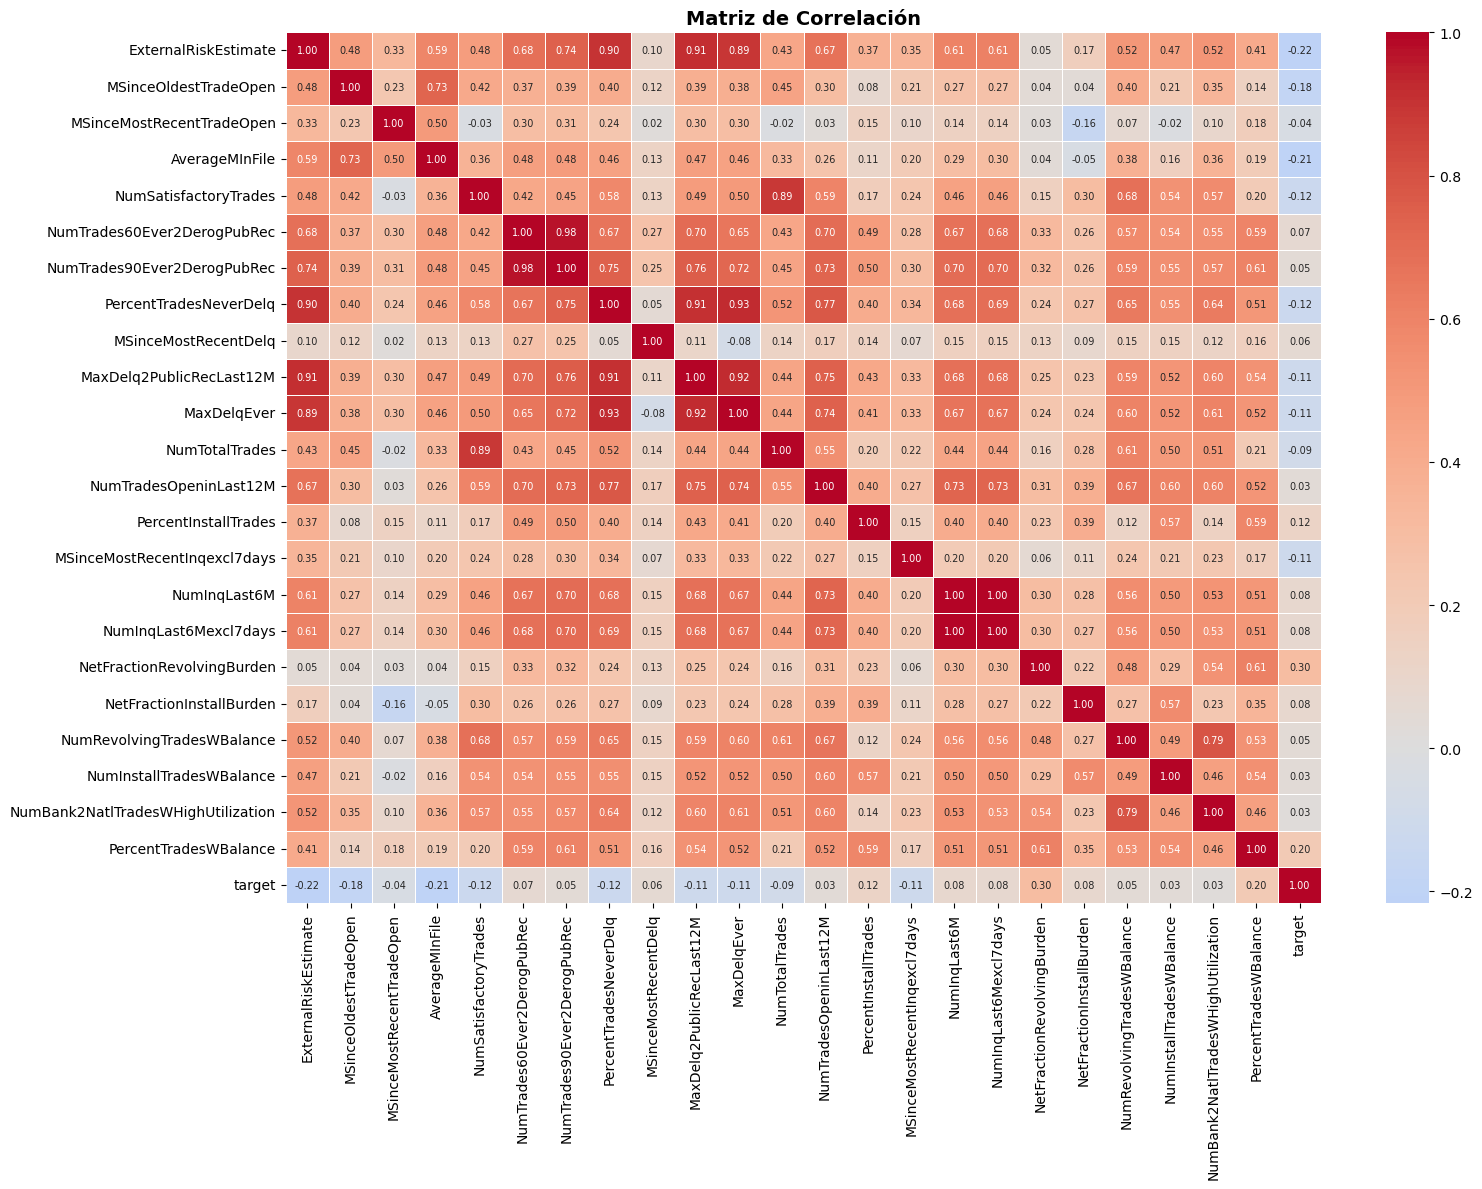

In [19]:
corr = df_eda.corr()
# Graficar
plt.figure(figsize=(16, 12))
sns.heatmap(corr, 
            annot=True,        # muestra los números
            fmt='.2f',         # 2 decimales
            cmap='coolwarm',   # azul=negativa, rojo=positiva
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
low_corr = corr.abs().unstack()
low_corr = low_corr[low_corr < 0.1] 
print(low_corr.sort_values(ascending=True).drop_duplicates)

<bound method Series.drop_duplicates of MSinceMostRecentTradeOpen           NumTotalTrades                        0.015343
NumTotalTrades                      MSinceMostRecentTradeOpen             0.015343
MSinceMostRecentDelq                MSinceMostRecentTradeOpen             0.020719
MSinceMostRecentTradeOpen           MSinceMostRecentDelq                  0.020719
                                    NumInstallTradesWBalance              0.021095
                                                                            ...   
NumTotalTrades                      target                                0.091818
ExternalRiskEstimate                MSinceMostRecentDelq                  0.095520
MSinceMostRecentDelq                ExternalRiskEstimate                  0.095520
MSinceMostRecentTradeOpen           NumBank2NatlTradesWHighUtilization    0.096361
NumBank2NatlTradesWHighUtilization  MSinceMostRecentTradeOpen             0.096361
Length: 64, dtype: float64>


In [21]:
low_corr.shape

(64,)

In [22]:
df_numeric = df_eda.copy()
corr_matrix = df_numeric.corr()
corr_matrix.head()

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,target
ExternalRiskEstimate,1.000000,0.478431,0.330719,0.589182,0.479007,0.682877,0.740853,0.897101,0.095520,0.911648,...,0.347114,0.609923,0.614112,0.045581,0.166208,0.515194,0.467710,0.523598,0.407782,-0.216401
MSinceOldestTradeOpen,0.478431,1.000000,0.228917,0.730298,0.417125,0.374660,0.385773,0.402028,0.118172,0.391117,...,0.212505,0.266457,0.270091,0.041075,0.039641,0.399838,0.212697,0.353339,0.140117,-0.182331
MSinceMostRecentTradeOpen,0.330719,0.228917,1.000000,0.495975,-0.027018,0.295955,0.305314,0.239793,0.020719,0.295712,...,0.100737,0.140296,0.141034,0.028016,-0.155949,0.066871,-0.021095,0.096361,0.177710,-0.044137
AverageMInFile,0.589182,0.730298,0.495975,1.000000,0.361495,0.475583,0.483724,0.455401,0.129617,0.472918,...,0.199261,0.293532,0.297667,0.038758,-0.045021,0.380314,0.160945,0.361293,0.193563,-0.206613
NumSatisfactoryTrades,0.479007,0.417125,-0.027018,0.361495,1.000000,0.420701,0.450345,0.581561,0.129132,0.485603,...,0.241313,0.457569,0.460242,0.154541,0.298286,0.678447,0.539082,0.565550,0.196990,-0.122391


In [23]:
# 1 — Correlación de cada feature con el target
print("Variables con más correlación con el target")
mas_corr_target = corr_matrix['target'].drop('target').sort_values() 
print(mas_corr_target[:10])

Variables con más correlación con el target
ExternalRiskEstimate           -0.216401
AverageMInFile                 -0.206613
MSinceOldestTradeOpen          -0.182331
NumSatisfactoryTrades          -0.122391
PercentTradesNeverDelq         -0.122188
MSinceMostRecentInqexcl7days   -0.112067
MaxDelq2PublicRecLast12M       -0.110527
MaxDelqEver                    -0.108082
NumTotalTrades                 -0.091818
MSinceMostRecentTradeOpen      -0.044137
Name: target, dtype: float64


In [24]:
corr_target = list(mas_corr_target[:10].index)

In [25]:
corr_target

['ExternalRiskEstimate',
 'AverageMInFile',
 'MSinceOldestTradeOpen',
 'NumSatisfactoryTrades',
 'PercentTradesNeverDelq',
 'MSinceMostRecentInqexcl7days',
 'MaxDelq2PublicRecLast12M',
 'MaxDelqEver',
 'NumTotalTrades',
 'MSinceMostRecentTradeOpen']

In [26]:
print("Pares de variables muy correlacionados")
high = corr_matrix.abs().unstack()
high = high[(high > 0.85) & (high < 1.0)].sort_values(ascending=False).drop_duplicates()
print(high)

Pares de variables muy correlacionados
NumInqLast6M                 NumInqLast6Mexcl7days          0.996924
NumTrades90Ever2DerogPubRec  NumTrades60Ever2DerogPubRec    0.975636
PercentTradesNeverDelq       MaxDelqEver                    0.927968
MaxDelq2PublicRecLast12M     MaxDelqEver                    0.924459
                             ExternalRiskEstimate           0.911648
PercentTradesNeverDelq       MaxDelq2PublicRecLast12M       0.907539
ExternalRiskEstimate         PercentTradesNeverDelq         0.897101
MaxDelqEver                  ExternalRiskEstimate           0.892572
NumSatisfactoryTrades        NumTotalTrades                 0.885119
dtype: float64


In [27]:
pares  =list(high.index)
pares

[('NumInqLast6M', 'NumInqLast6Mexcl7days'),
 ('NumTrades90Ever2DerogPubRec', 'NumTrades60Ever2DerogPubRec'),
 ('PercentTradesNeverDelq', 'MaxDelqEver'),
 ('MaxDelq2PublicRecLast12M', 'MaxDelqEver'),
 ('MaxDelq2PublicRecLast12M', 'ExternalRiskEstimate'),
 ('PercentTradesNeverDelq', 'MaxDelq2PublicRecLast12M'),
 ('ExternalRiskEstimate', 'PercentTradesNeverDelq'),
 ('MaxDelqEver', 'ExternalRiskEstimate'),
 ('NumSatisfactoryTrades', 'NumTotalTrades')]

In [28]:
# Esto ya lo corriste antes
corr_target = df_numeric.corr()['target'].drop('target')
top_features = corr_target.abs().sort_values(ascending=False).head(10).index.tolist()

In [29]:
# De cada par, eliminar el que tenga MENOR correlación con el target
eliminar = set()
for a, b in pares:
    corr_a = abs(corr_target.get(a, 0))
    corr_b = abs(corr_target.get(b, 0))
    descartada = b if corr_a >= corr_b else a
    eliminar.add(descartada)

# Features finales = top_features - los descartados por multicolinealidad
features_finales = [f for f in top_features if f not in eliminar]

print(f' Eliminadas por multicolinealidad: {eliminar}')
print(f'\n Features finales ({len(features_finales)}):')
for f in features_finales:
    print(f'   {f}')

# Guardar X e y listos para el modelo
X = df[features_finales]
y = df['target']
print(f'\n Shape X: {X.shape}')
print(f' Shape y: {y.shape}')

 Eliminadas por multicolinealidad: {'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'PercentTradesNeverDelq', 'NumInqLast6Mexcl7days', 'NumTotalTrades', 'NumTrades90Ever2DerogPubRec'}

 Features finales (8):
   NetFractionRevolvingBurden
   ExternalRiskEstimate
   AverageMInFile
   PercentTradesWBalance
   MSinceOldestTradeOpen
   NumSatisfactoryTrades
   PercentInstallTrades
   MSinceMostRecentInqexcl7days

 Shape X: (10459, 8)
 Shape y: (10459,)


In [30]:
features_finales

['NetFractionRevolvingBurden',
 'ExternalRiskEstimate',
 'AverageMInFile',
 'PercentTradesWBalance',
 'MSinceOldestTradeOpen',
 'NumSatisfactoryTrades',
 'PercentInstallTrades',
 'MSinceMostRecentInqexcl7days']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
DATA_PROCESSED = ROOT / 'data' / 'processed'

In [34]:
X_train.to_csv(DATA_PROCESSED/'X_train.csv', index=False)
X_test.to_csv(DATA_PROCESSED/'X_test.csv', index=False)
y_train.to_csv(DATA_PROCESSED/'y_train.csv', index=False)
y_test.to_csv(DATA_PROCESSED/'y_test.csv', index=False)